### IMPORT LIBRARIES

In [27]:
import plistlib
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
from matplotlib.lines import Line2D
from collections import defaultdict, OrderedDict

### LOAD THE MUSIC LIBRARY

In [28]:
with open('../data/Library.xml', 'rb') as file:
    plist = plistlib.load(file)

### CONVERT LIBRARY DATA INTO A DATAFRAME

In [29]:
tracks = plist['Tracks']
song_df = pd.DataFrame(tracks).T  # Transpose so each track is a row

### HELPER FUNCTIONS

In [30]:
def ms_to_min(ms) -> str:
    """Convert milliseconds to mm:ss format."""
    
    if pd.isna(ms): # Check for NaN
        return None
    seconds = ms / 1000
    minutes = seconds // 60
    rem_seconds = seconds % 60
    
    return f"{int(minutes)}:{int(rem_seconds):02d}"

def ms_to_hours(ms) -> str:
    """Convert milliseconds to a readable format with days, hours, etc."""
    
    if pd.isna(ms) or ms <= 0: # Check for NaN or zero
        return "0s"
    
    seconds = int(ms / 1000) # Convert milliseconds to seconds
    
    years, rem = divmod(seconds, 31536000) # divide by seconds in a year
    months, rem = divmod(rem, 2592000) # divide by seconds in a month
    days, rem = divmod(rem, 86400) # divide by seconds in a day
    hours, rem = divmod(rem, 3600) # divide by seconds in an hour
    minutes, rem = divmod(rem, 60) # divide by seconds in a minute
    secs = rem # remaining seconds
    
    parts = []
    
    if years:
        parts.append(f"{years}y")
    if months:
        parts.append(f"{months}mo")
    if days:
        parts.append(f"{days}d")
    if hours:
        parts.append(f"{hours}h")
    if minutes:
        parts.append(f"{minutes}m")
    if secs:
        parts.append(f"{secs}s")

    return ' '.join(parts) # join parts together with spaces

def bytes_to_megabytes(bytes) -> float:
    """Convert bytes to megabytes."""
    
    if pd.isna(bytes): # Check for NaN
        return None
    return round(bytes / (1024 * 1024), 2) # Convert bytes to MB and round to 2 decimal places

def get_quadrant(row, x_median, y_median) -> str:
    """Determine the quadrant based on play count and skip count."""
    
    # Sort the row into quadrants based on median values
    if row['Play Count'] >= x_median and row['Skip Rate'] >= y_median:
        return 'Popular but Skipped'
    elif row['Play Count'] >= x_median and row['Skip Rate'] < y_median:
        return 'Favorites'
    elif row['Play Count'] < x_median and row['Skip Rate'] >= y_median:
        return 'Ignored & Skipped'
    else:
        return 'Slow Burners'

def extract_all_artists(row) -> list:
    """Extract all artists from the 'Artist' and 'Name' fields."""

    # normalize common misspellings and variations to improve deduplication
    normalize_map = {
        'tyler, the creator': 'Tyler, the Creator',
        "bj the chicago kid": "BJ the Chicago Kid",
        "freekey zekey": "Freekey Zeekey",
        "beyoncé knowles": "Beyoncé",
        "bossman dlow": "Bossman Dlow",
        "bnxn fka buju": "BNXN",
        "bxnx fka buju": "BNXN",
        "buju": "BNXN",
        "jay z": "JAY-Z",
        "snoop doggy dogg": "Snoop Dogg",
        "rio da young og": "Rio da Yung OG",
        "rio da yung og": "Rio da Yung OG",
        "rich the kid": "Rich the Kid",
        "young sinatra": "Logic",
        "young jeezy": "Jeezy",
        "ty dolla $ign": "Ty Dolla $ign",
        "Pharrell": "Pharrell Williams",
        "RIHANNA.": "Rihanna",
    }

    # Keep original strings for output
    artist_raw = str(row['Artist'])
    name_raw   = str(row['Name'])
    
    # normalize full artist string before splitting
    key_full = artist_raw.lower().strip()
    if key_full in normalize_map:
        artist_raw = normalize_map[key_full]
        
    # Remove anything inside brackets (ex: [Remix], [Bonus Track])
    name_raw = re.sub(r"\[.*?\]", "", name_raw)

    # Lowercase copies for searching
    search_name = name_raw.lower()

    ### 1. Extract main artists ###
    
    # Split the 'Artist' field by common delimiters
    # Artists that contain commas but are NOT collaborations
    protected_comma_artists = {
        "Tyler, the Creator",
    }

    if artist_raw in protected_comma_artists:
        main_artists = [artist_raw]
    else:
        main_artists = re.split(r', (?=[A-Z])| & | and | x ', artist_raw)

    ### 2. Extract featured artists ###
    
    # Use regex to find featured artists in the Song 'Name' field
    feat_pattern = r"\b(feat\.|featuring|ft\.)\s*([^\(\)]+)"
    feat_artists = []

    # search for the pattern in the original name string to get correct indices
    match = re.search(feat_pattern, search_name)
    if match:
        start = match.start(2)              # get index of group(2)
        featured_part = name_raw[start:]    # slice from original string
        feat_artists = re.split(r',|&| and | x ', featured_part, flags=re.IGNORECASE)

    # Remove featured artist info from the name to avoid confusion
    name_raw = re.sub(r"\((feat\.|featuring|ft\.).*?\)", "", name_raw, flags=re.IGNORECASE)
    
    # Clean up names
    all_artists = main_artists + feat_artists
    cleaned_artists = []

    for artist in all_artists:
        artist = artist.strip()
        
        # Remove unmatched trailing closing parentheses
        while artist.endswith(")") and artist.count(")") > artist.count("("):
            artist = artist[:-1]

        # Remove unmatched leading opening parentheses
        while artist.startswith("(") and artist.count("(") > artist.count(")"):
            artist = artist[1:]
        
        # Remove junk
        artist = re.sub(r"[^\w\s'\-&¥$\.!()/]", '', artist)
        # Remove whitespace
        artist = re.sub(r'\s{2,}', ' ', artist)

        # if the artist is in the normalize map, replace it with the normalized version
        key = artist.lower()
        if key in normalize_map:
            artist = normalize_map[key]
        if artist:
            cleaned_artists.append(artist)

    # Deduplicate while preserving order
    return list(OrderedDict.fromkeys(cleaned_artists))

def get_genre_diversity(genre_counts) -> float:
    """Calculate the raw entropy-based diversity score of genre play counts.

    This score quantifies how evenly plays are distributed across genres. Higher values indicate greater diversity. Not normalized by genre count.
    """
    
    probs = genre_counts / genre_counts.sum()
    entropy = -sum(probs * np.log2(probs))
    
    return entropy

### CLEAN UP DATAFRAME

In [31]:
# Set 'Track ID' as index
song_df.set_index('Track ID', inplace=True)

# Drop irrelevant columns
song_df = song_df.drop(columns=['Kind', 'Disc Number', 'Disc Count', 'Date Modified', 'Bit Rate', 'Sample Rate', 'Play Date', 'Artwork Count', 'Sort Album', 'Sort Artist', 'Sort Name', 'Persistent ID', 'Track Type', 'Apple Music', 'Normalization', 'Loved', 'Sort Album Artist', 'Compilation', 'Stop Time', 'Clean', 'Sort Composer', 'Comments', 'Matched', 'Volume Adjustment', 'Album Loved', 'Playlist Only', 'Album Rating', 'Album Rating Computed', 'Rating', 'Location', 'File Folder Count', 'Library Folder Count', 'Grouping', ])

# Fill NaN values
song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']] = song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']].fillna(False)
song_df[['Skip Count', 'Play Count']] = song_df[['Skip Count', 'Play Count']].fillna(0)

# Convert data types
song_df['Play Count'] = song_df['Play Count'].astype(int)
song_df['Skip Count'] = song_df['Skip Count'].astype(int)
song_df['Explicit'] = song_df['Explicit'].astype(bool)
song_df['Favorited'] = song_df['Favorited'].astype(bool)
song_df['Part Of Gapless Album'] = song_df['Part Of Gapless Album'].astype(bool)

# Calculate total listening time
song_df['Listening Time (ms)'] = pd.to_numeric(song_df['Total Time']) * song_df['Play Count']
song_df['Listening Time'] = song_df['Listening Time (ms)'].apply(ms_to_hours)

# Convert 'Total Time' and 'Size' to a readable format
song_df['Total Time'] = pd.to_numeric(song_df['Total Time'])
song_df['Total Time'] = song_df['Total Time'].apply(ms_to_min)
song_df['Size'] = song_df['Size'].apply(bytes_to_megabytes)

# Rename columns for clarity
song_df.rename(columns={'Total Time': 'Time'}, inplace=True)
song_df.rename(columns={'Size': 'Size (MB)'}, inplace=True)
song_df.rename(columns={'Play Date UTC': 'Play Date'}, inplace=True)

# Convert date columns to datetime
song_df['Date Added'] = pd.to_datetime(song_df['Date Added'], errors='coerce')
song_df['Play Date'] = pd.to_datetime(song_df['Play Date'], errors='coerce').fillna(song_df['Date Added'])

# Add 'All Artists' column
song_df['All Artists'] = song_df.apply(extract_all_artists, axis=1)

/var/folders/rr/jdwhvnl573n1cmxbksk2ypgc0000gn/T/ipykernel_49287/2850825075.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']] = song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']].fillna(False)
/var/folders/rr/jdwhvnl573n1cmxbksk2ypgc0000gn/T/ipykernel_49287/2850825075.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  song_df[['Skip Count', 'Play Count']] = song_df[['Skip Count', 'Play Count']].fillna(0)


In [32]:
# Create a column for all artists involved in a track
song_df['All Artists'] = song_df.apply(extract_all_artists, axis=1)

# Create a dict for counts
artist_totals = defaultdict(lambda: {'Play Count': 0, 'Skip Count': 0})

# Map total play and skip counts for each artist
for _, row in song_df.iterrows():
    for artist in row['All Artists']:
        artist_totals[artist]['Play Count'] += int(row['Play Count'] or 0)
        artist_totals[artist]['Skip Count'] += int(row['Skip Count'] or 0)

# Use a new variable name
artist_df = pd.DataFrame.from_dict(artist_totals, orient='index').astype(int)
artist_df.index.name = 'Artist'
artist_df = artist_df.sort_values(by='Artist', ascending=True)

In [33]:
artist_df

,Play Count,Skip Count
Artist,,
((( O ))),6,5
112,16,13
1wayfrank,5,3
2 Chainz,365,117
21 Savage,786,249
...,...,...
the Creator,16,6
tommy,12,4
twenty one pilots,28,7


In [34]:
artists = artist_df.index.to_frame().to_csv('../data/artists.csv', index=False)


### MAP GENRES TO BROADER CATEGORIES

In [35]:
genre_map = {
    'Rap': 'Hip-Hop/Rap',
    'Hip-Hop': 'Hip-Hop/Rap',
    'Gangsta Rap': 'Hip-Hop/Rap',
    'Alternative Rap': 'Hip-Hop/Rap',
    'Hip Hop/Rap': 'Hip-Hop/Rap',
    'Dirty South': 'Hip-Hop/Rap',
    'Hardcore Rap': 'Hip-Hop/Rap',
    'Hardcore': 'Hip-Hop/Rap',
    'Soul': 'R&B/Soul',
    'Electronic': 'EDM',
    'Electronica': 'EDM',
    'Dance': 'EDM',
    'Amapiano': 'Afrobeats',
    'House': 'EDM',
    'Pop': 'Pop',
    'Alt. Rock': 'Alternative',
    'Indie Rock': 'Alternative',
    'Singer/Songwriter': 'Alternative',
    'Europe': 'Alternative',
    'Techno': 'Alternative',
    'Metal': 'Rock',
    'Hard Rock': 'Rock',
    'Worldwide': 'Afrobeats',
    'Afro-fusion': 'Afrobeats',
    'African': 'Afrobeats',
    'Alte': 'Afrobeats',
    'Afro-Beat': 'Afrobeats',
    'Afro-Pop': 'Afrobeats',
    'Reggae': 'Afrobeats',
    'Highlife': 'Afrobeats',
    'Urbano latino': 'Latin',
    'Indie Pop': 'Pop',
    'Soundtrack': 'Other',
    'New Wave': 'Other',
    'Holiday': 'Other',
    'TV Soundtrack': 'Other',
    'Pop/Rock': 'Pop',
}

### NORMALIZE GENRES AND GET PLAY COUNTS

In [36]:
# Create a new column for normalized genres
song_df['Normalized Genre'] = song_df['Genre'].map(genre_map).fillna(song_df['Genre'])
genre_counts = song_df.groupby('Normalized Genre')['Play Count'].sum().astype(int).sort_values(ascending=False)

In [37]:
song_df

,Name,Artist,Album Artist,Composer,Album,Genre,Size (MB),Time,Track Number,Track Count,...,Skip Date,Release Date,Explicit,Favorited,Part Of Gapless Album,Disliked,Listening Time (ms),Listening Time,All Artists,Normalized Genre
Track ID,,,,,,,,,,,,,,,,,,,,,
2521,HUMBLE.,Kendrick Lamar,Kendrick Lamar,"Kendrick Lamar, A. Hogan, Michael L. Williams ...",DAMN.,Hip-Hop/Rap,6.09,2:57,8,14,...,2024-06-10 22:51:25,2017-03-31 07:00:00,True,False,False,NaN,3540000,59m,[Kendrick Lamar],Hip-Hop/Rap
2523,DNA.,Kendrick Lamar,Kendrick Lamar,K. Duckworth & M. Williams II,DAMN.,Hip-Hop/Rap,6.42,3:05,2,14,...,2026-01-15 16:24:29,2017-04-14 12:00:00,True,False,False,NaN,3718940,1h 1m 58s,[Kendrick Lamar],Hip-Hop/Rap
2525,Mask Off,Future,Future,"Nayvadius Wilburn, Leland Wayne & Tommy Butler",FUTURE,Hip-Hop/Rap,6.97,3:24,7,20,...,2023-05-26 07:06:50,2017-02-17 08:00:00,True,False,False,NaN,3069000,51m 9s,[Future],Hip-Hop/Rap
2527,Congratulations (feat. Quavo),Post Malone,Post Malone,"Austin Post, Louis Bell, Adam Feeney, Quavious...",Stoney (Deluxe),Hip-Hop/Rap,7.49,3:40,12,18,...,2024-01-31 06:37:47,2016-11-04 07:00:00,True,True,False,NaN,7269405,2h 1m 9s,"[Post Malone, Quavo]",Hip-Hop/Rap
2529,Portland (feat. Quavo & Travis Scott),Drake,Drake,"Aubrey Drake Graham, Q. Marshall, J. Webster, ...",More Life,Hip-Hop/Rap,7.97,3:56,11,22,...,2024-02-09 19:03:43,2017-03-18 12:00:00,True,False,False,NaN,6151990,1h 42m 31s,"[Drake, Quavo, Travis Scott]",Hip-Hop/Rap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23005,TOP OPTION BOYZ,"Concrete Boys, Camo!, DontKallMeLuxxy & Lil Ya...",Concrete Boys,"Miles McCollum, Cameron Butts, ROGER BRADLEY, ...",It's Us Vol. 2,Hip-Hop/Rap,5.95,2:51,12,16,...,NaN,2026-02-27 12:00:00,True,False,False,NaN,0,0s,"[Concrete Boys, Camo!, DontKallMeLuxxy, Lil Ya...",Hip-Hop/Rap
23007,Choosin' Texas,Ella Langley,Ella Langley,"Ella Langley, Luke Dick, Miranda Lambert & Joy...",Choosin' Texas - Single,Country,7.87,3:52,1,1,...,NaN,2025-10-17 12:00:00,False,False,False,NaN,0,0s,[Ella Langley],Country
23009,Over You,Vacations,Vacations,"John Velasquez, Campbell James Burns & Nathan ...",No Place Like Home (From the Motel),Indie Rock,5.20,2:26,4,10,...,NaN,2024-01-12 12:00:00,False,False,False,NaN,0,0s,[Vacations],Alternative


In [38]:
diversity_score = get_genre_diversity(genre_counts)
print(f"Genre Diversity Score: {diversity_score:.3f}")

Genre Diversity Score: 1.299


In [39]:
print("List of Available Styles : {}". format(plt.style.available))
plt.style.use('seaborn-v0_8-ticks')

List of Available Styles : ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


# GENRE STATS

### PLOT TOP GENRES BY LISTENING TIME

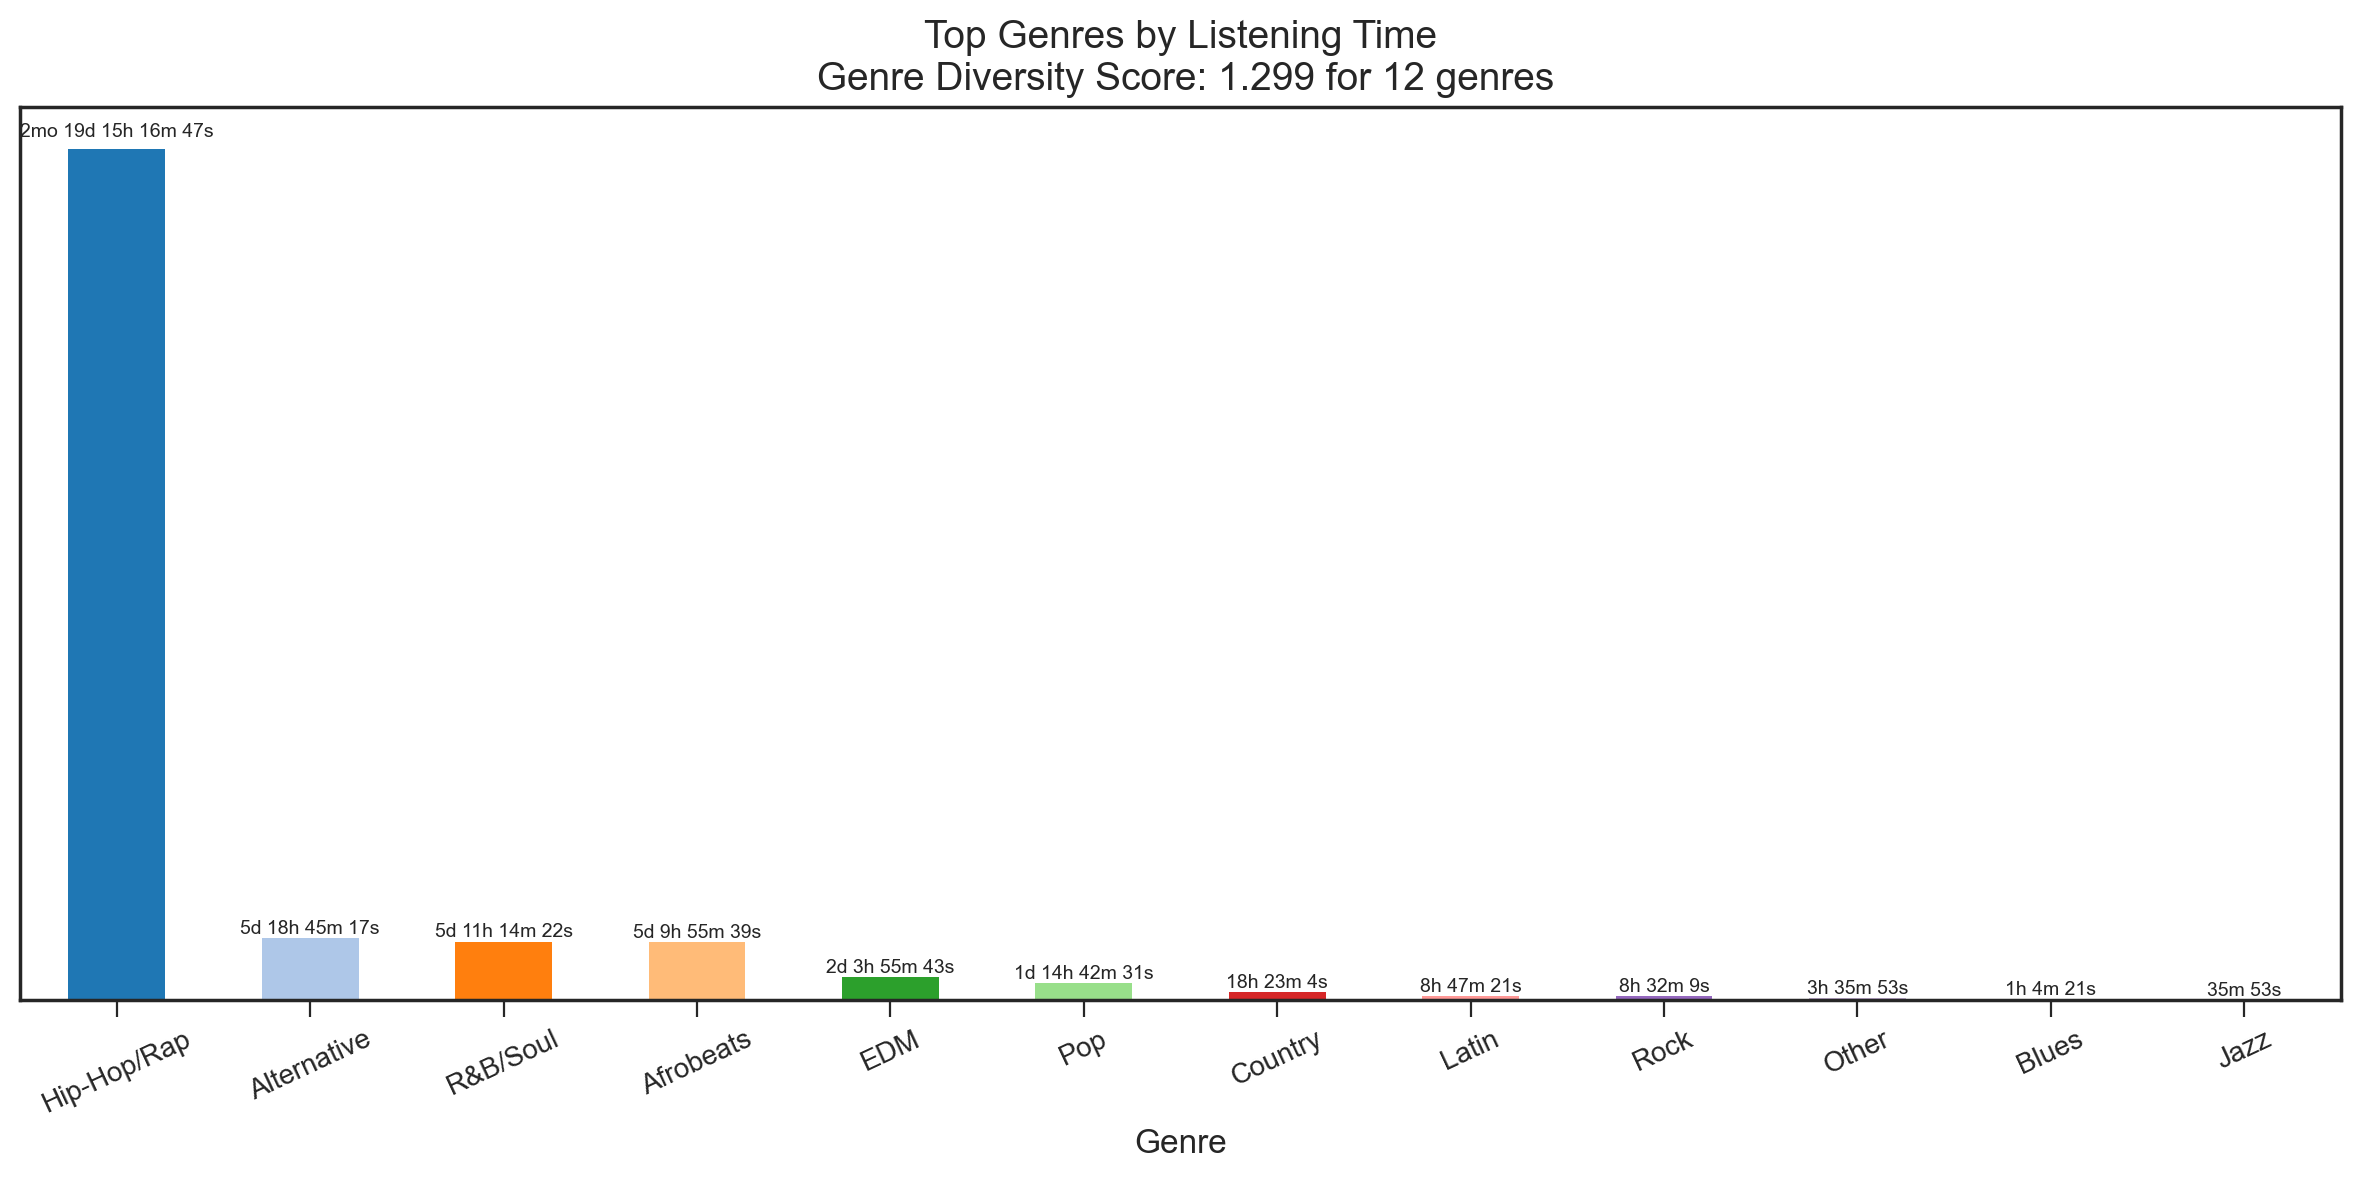

In [40]:
genre_time = song_df.groupby('Normalized Genre')[['Listening Time (ms)']].sum().sort_values(ascending=False, by='Listening Time (ms)')

plt.figure(dpi=200, figsize=(12,6))

genre_time['Listening Time (ms)'].plot(kind='bar', color=cm.tab20.colors)

for i, value in enumerate(genre_time['Listening Time (ms)']):
    label = ms_to_hours(value)
    plt.text(i, value + value * 0.01, label, ha='center', va='bottom', fontsize=7)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=25, fontsize=10)
plt.yticks([])
plt.title(f'Top Genres by Listening Time\n Genre Diversity Score: {diversity_score:.3f} for {len(genre_time)} genres', fontsize=14)
plt.tight_layout()

# ARTIST STATS

### PLOT TOP 15 ARTISTS BY LISTENING TIME

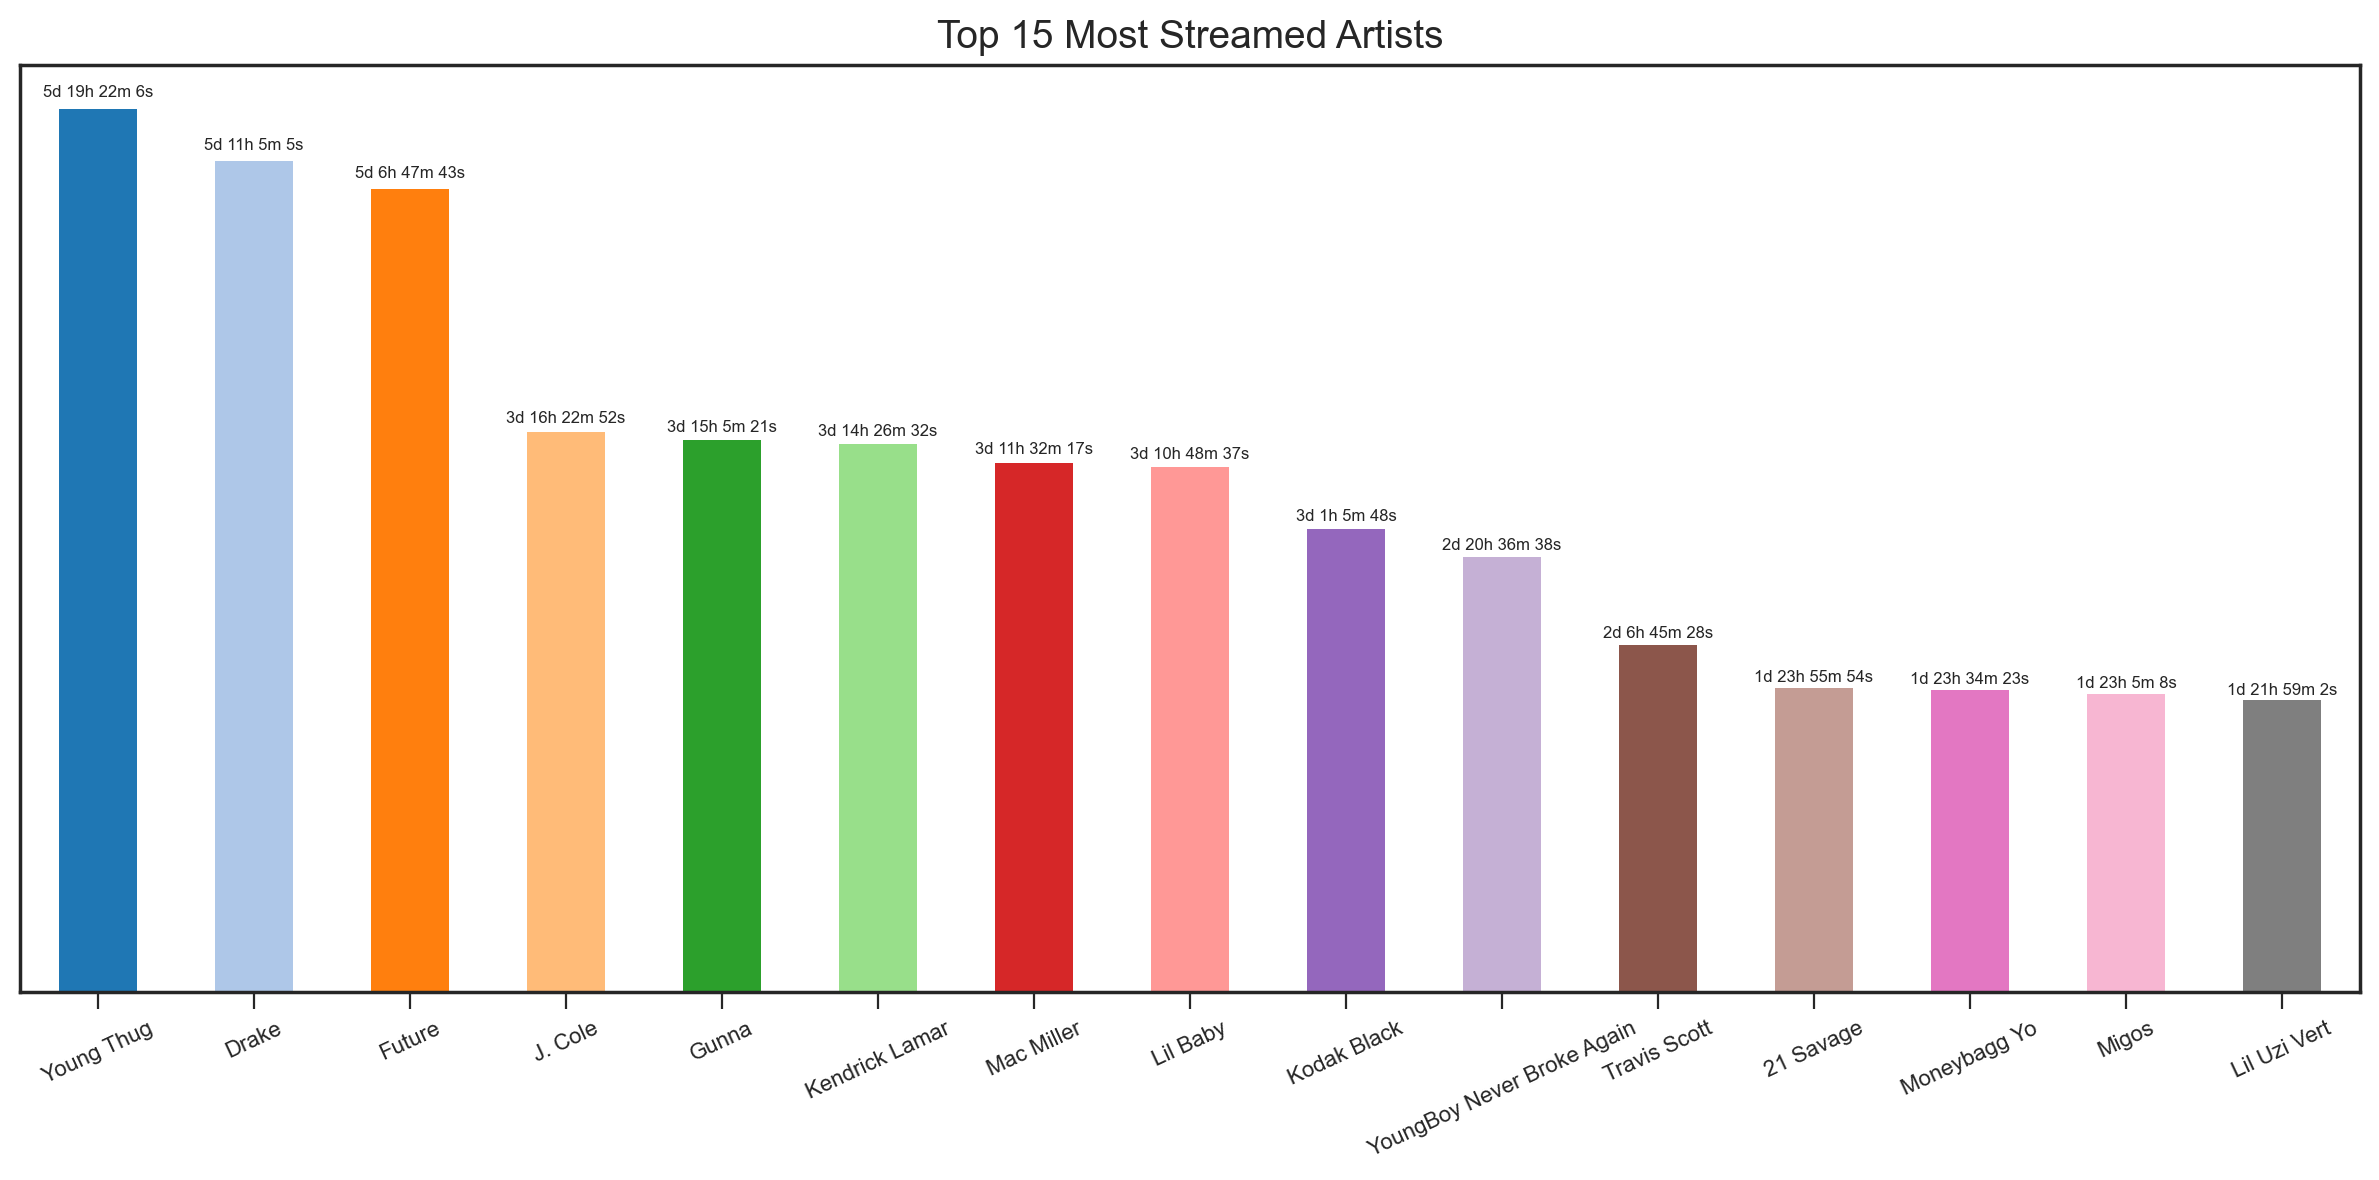

In [42]:
# Reset index to make 'Artist' a column
artist_df = artist_df.reset_index()

# Create a dict to hold artist listening time
artist_listening = defaultdict(int)

# Calculate total listening time for each artist
for _, row in song_df.iterrows():
    for artist in row['All Artists']:
        artist_listening[artist] += int(row['Listening Time (ms)'] or 0)

# Create a new column for artist total listening time
artist_df['Listening Time (ms)'] = artist_df['Artist'].map(artist_listening).fillna(0).astype(int)
artist_df['Listening Time'] = artist_df['Listening Time (ms)'].apply(ms_to_hours)

# Sort artists by total listening time and get the top 15
artists = artist_df.groupby('Artist')['Listening Time (ms)'].sum().sort_values(ascending=False)
artists = artists.head(15)

# Plot the top 15
plt.figure(dpi=200, figsize=(12,6))
artists.plot(kind='bar', color=cm.tab20.colors)
for i, value in enumerate(artists):
    label = ms_to_hours(value)
    plt.text(i, value + value * 0.01, label, ha='center', va='bottom', fontsize=6)
plt.xlabel('')
plt.xticks(rotation=25, fontsize=8)
plt.yticks([])
plt.title('Top 15 Most Streamed Artists', fontsize=14)
plt.tight_layout()


### PLOT PLAY COUNT VS SKIP RATE BY ARTIST

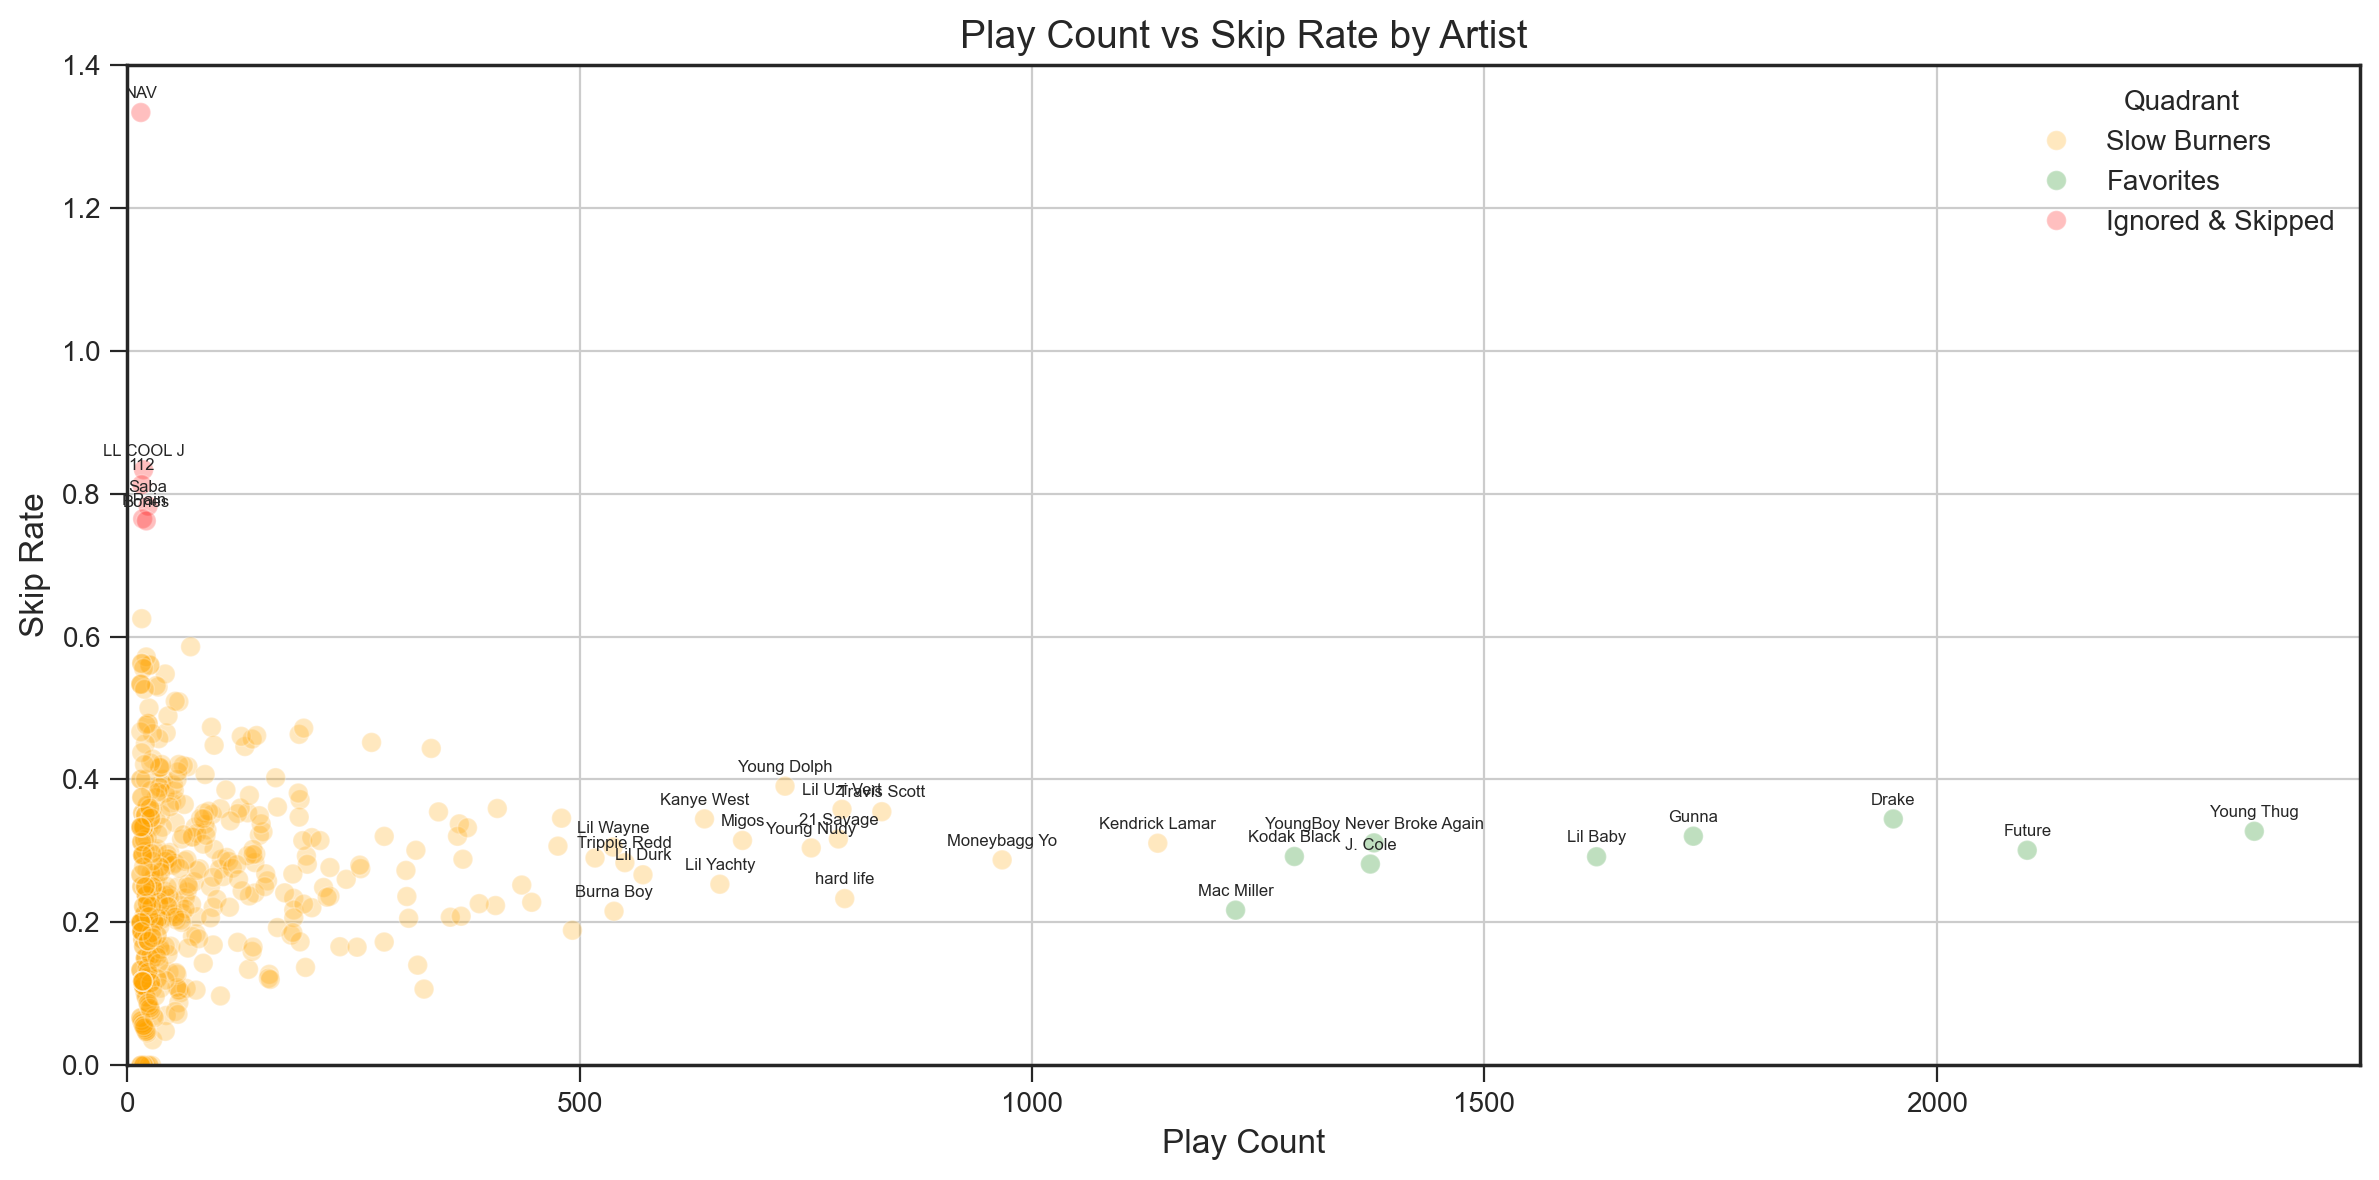

In [43]:
# Convert to DataFrame
artist_stats = pd.DataFrame.from_dict(artist_totals, orient='index').astype(int)
artist_stats.index.name = 'Artist'
artist_stats = artist_stats.reset_index()

# Filter out artists with no plays or skips
artist_stats = artist_stats[(artist_stats['Play Count'] > 0) | (artist_stats['Skip Count'] > 0)]

# Create Skip Rate
artist_stats['Skip Rate'] = artist_stats['Skip Count'] / artist_stats['Play Count']

# Optional: filter very low-play artists so skip rate isn't noisy
artist_stats = artist_stats[artist_stats['Play Count'] >= 15]

# Calculate midpoints for the axis
x_median = artist_stats['Play Count'].max() / 2
y_median = artist_stats['Skip Rate'].max() / 2

# Assign quadrants based on play count and skip count
artist_stats['Quadrant'] = artist_stats.apply(lambda row: get_quadrant(row, x_median, y_median), axis=1)


plt.figure(figsize=(12, 6), dpi=200)

# Create a color palette for the quadrants
palette = {
    'Favorites': 'green',
    'Popular but Skipped': 'blue',
    'Ignored & Skipped': 'red',
    'Slow Burners': 'orange'
}

sns.scatterplot(data=artist_stats, x='Play Count', y='Skip Rate', hue='Quadrant', palette=palette, alpha=0.25, s=50)

for quadrant in artist_stats['Quadrant'].unique():
    
    subset = artist_stats[artist_stats['Quadrant'] == quadrant]
    
    top_artists = subset.nlargest(15, 'Play Count')
    
    for _, row in top_artists.iterrows():
        plt.text(
            row['Play Count'],
            row['Skip Rate'] + 0.02,
            row['Artist'],
            fontsize=6,
            ha='center'
        )

plt.xlabel('Play Count', fontsize=12)
plt.ylabel('Skip Rate', fontsize=12)
plt.title('Play Count vs Skip Rate by Artist', fontsize=14)
plt.legend(title='Quadrant', loc='upper right')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(True)
plt.tight_layout()
plt.show()

### PLOT LISTENING SHARE BY NUMBER OF ARTISTS

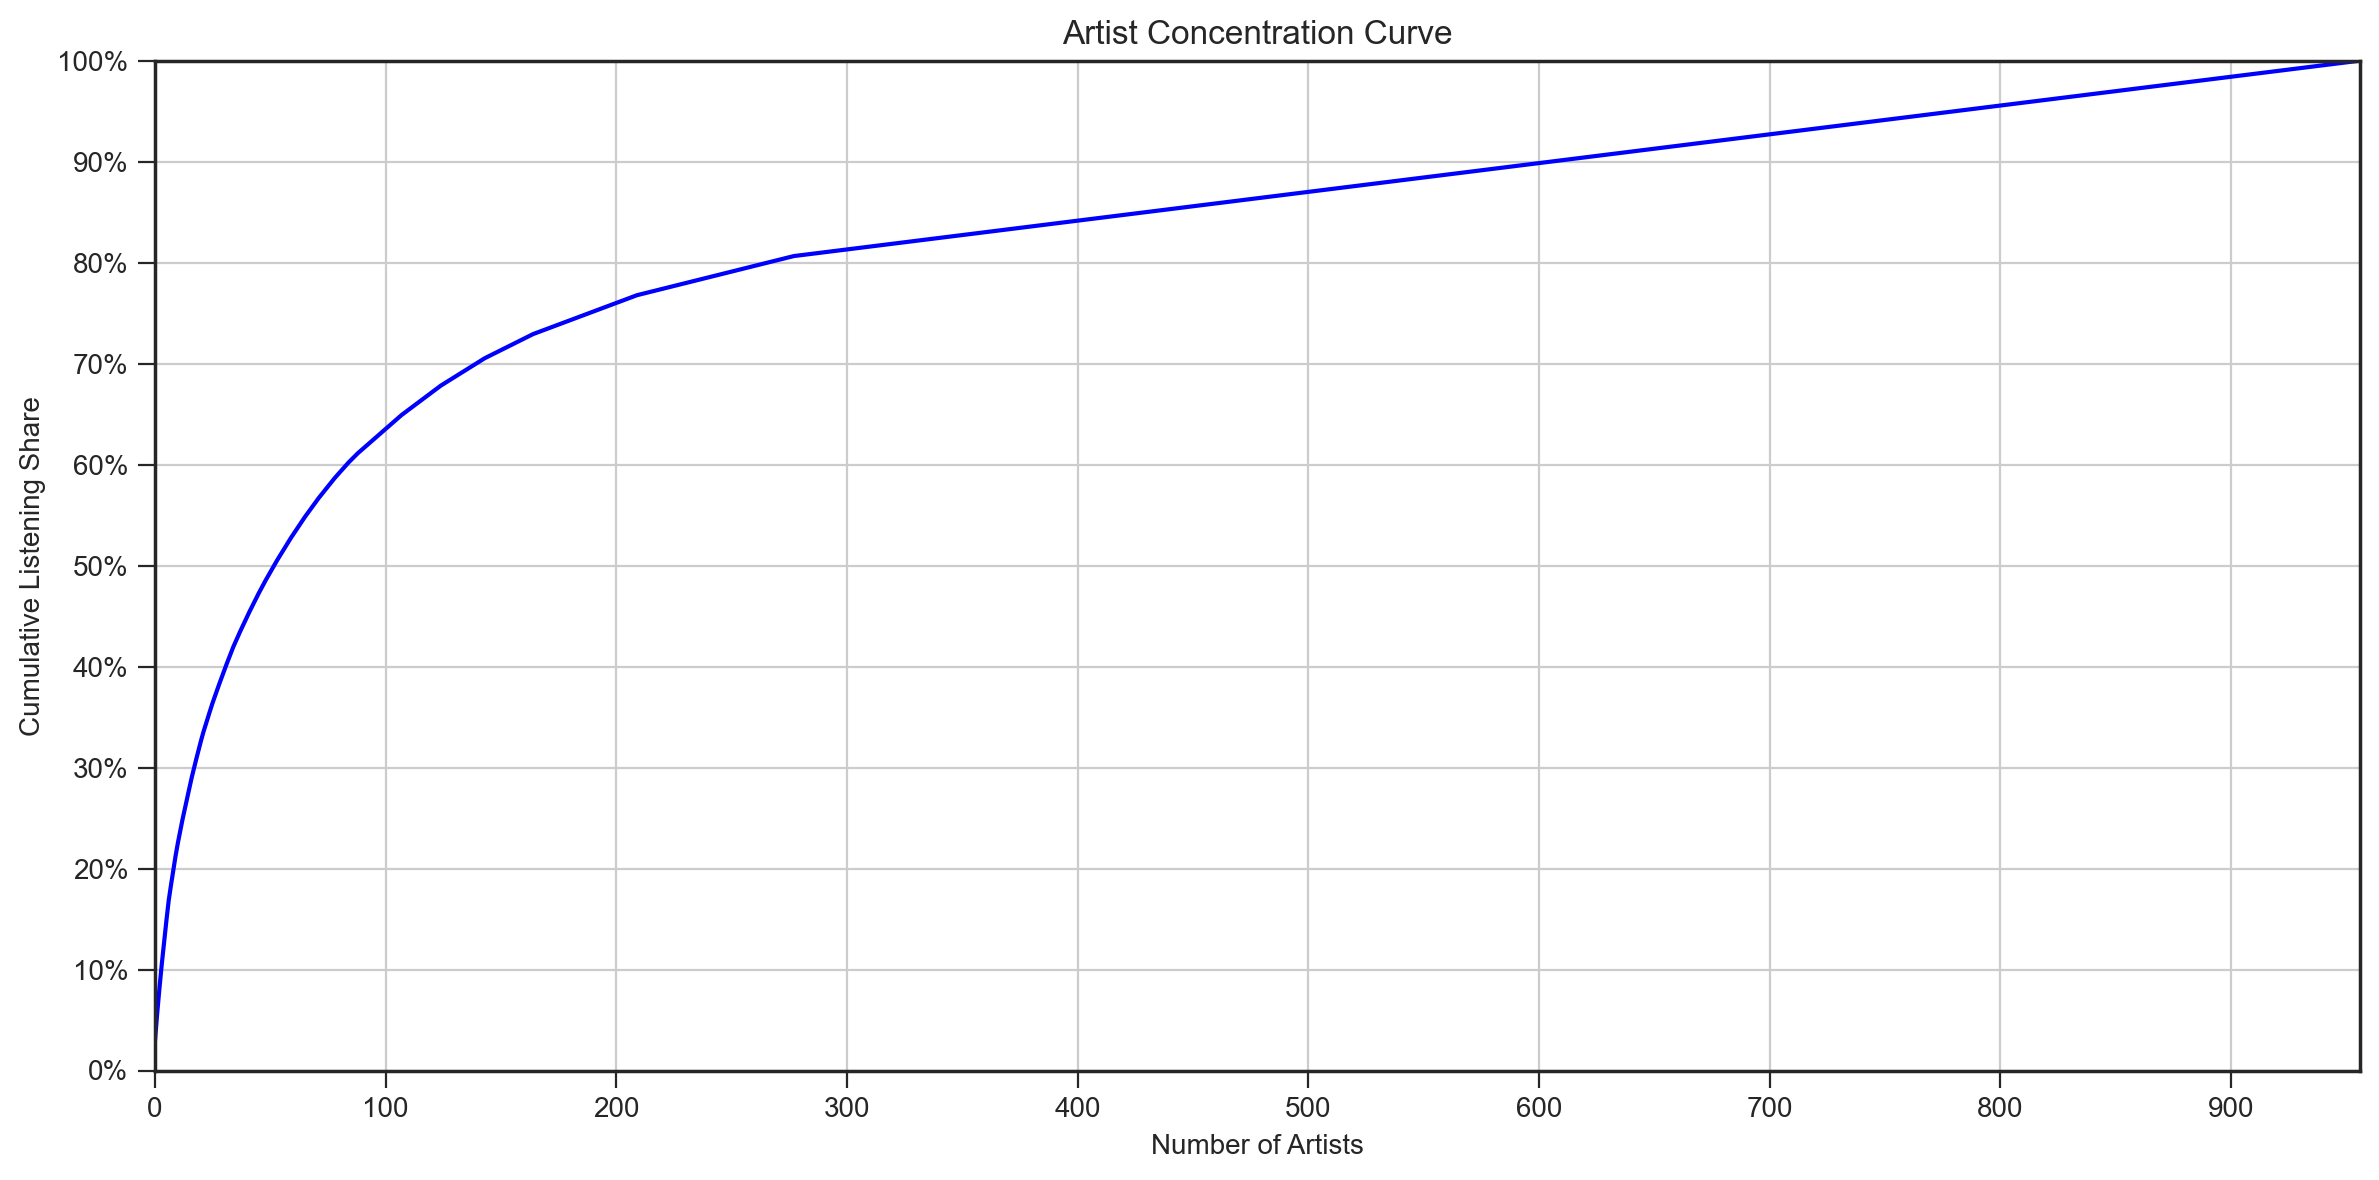

In [55]:
artist_counts = song_df['Artist'].value_counts()

shares = artist_counts / artist_counts.sum()
cumulative = shares.cumsum()

plt.figure(figsize=(12, 6), dpi=200)
plt.xlabel("Number of Artists")
plt.ylabel("Cumulative Listening Share")
plt.title("Artist Concentration Curve")
plt.plot(range(len(cumulative)), (cumulative * 100), color='blue')
plt.margins(x=0)
plt.grid(True)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10), [f"{y}%" for y in range(0, 101, 10)])
plt.xticks(range(0, len(cumulative) + 1, 100))
plt.tight_layout()
plt.show()


# ALBUM STATS

### PLOT TOP 10 ALBUMS WITH HIGHEST AVERAGE REPLAY RATE

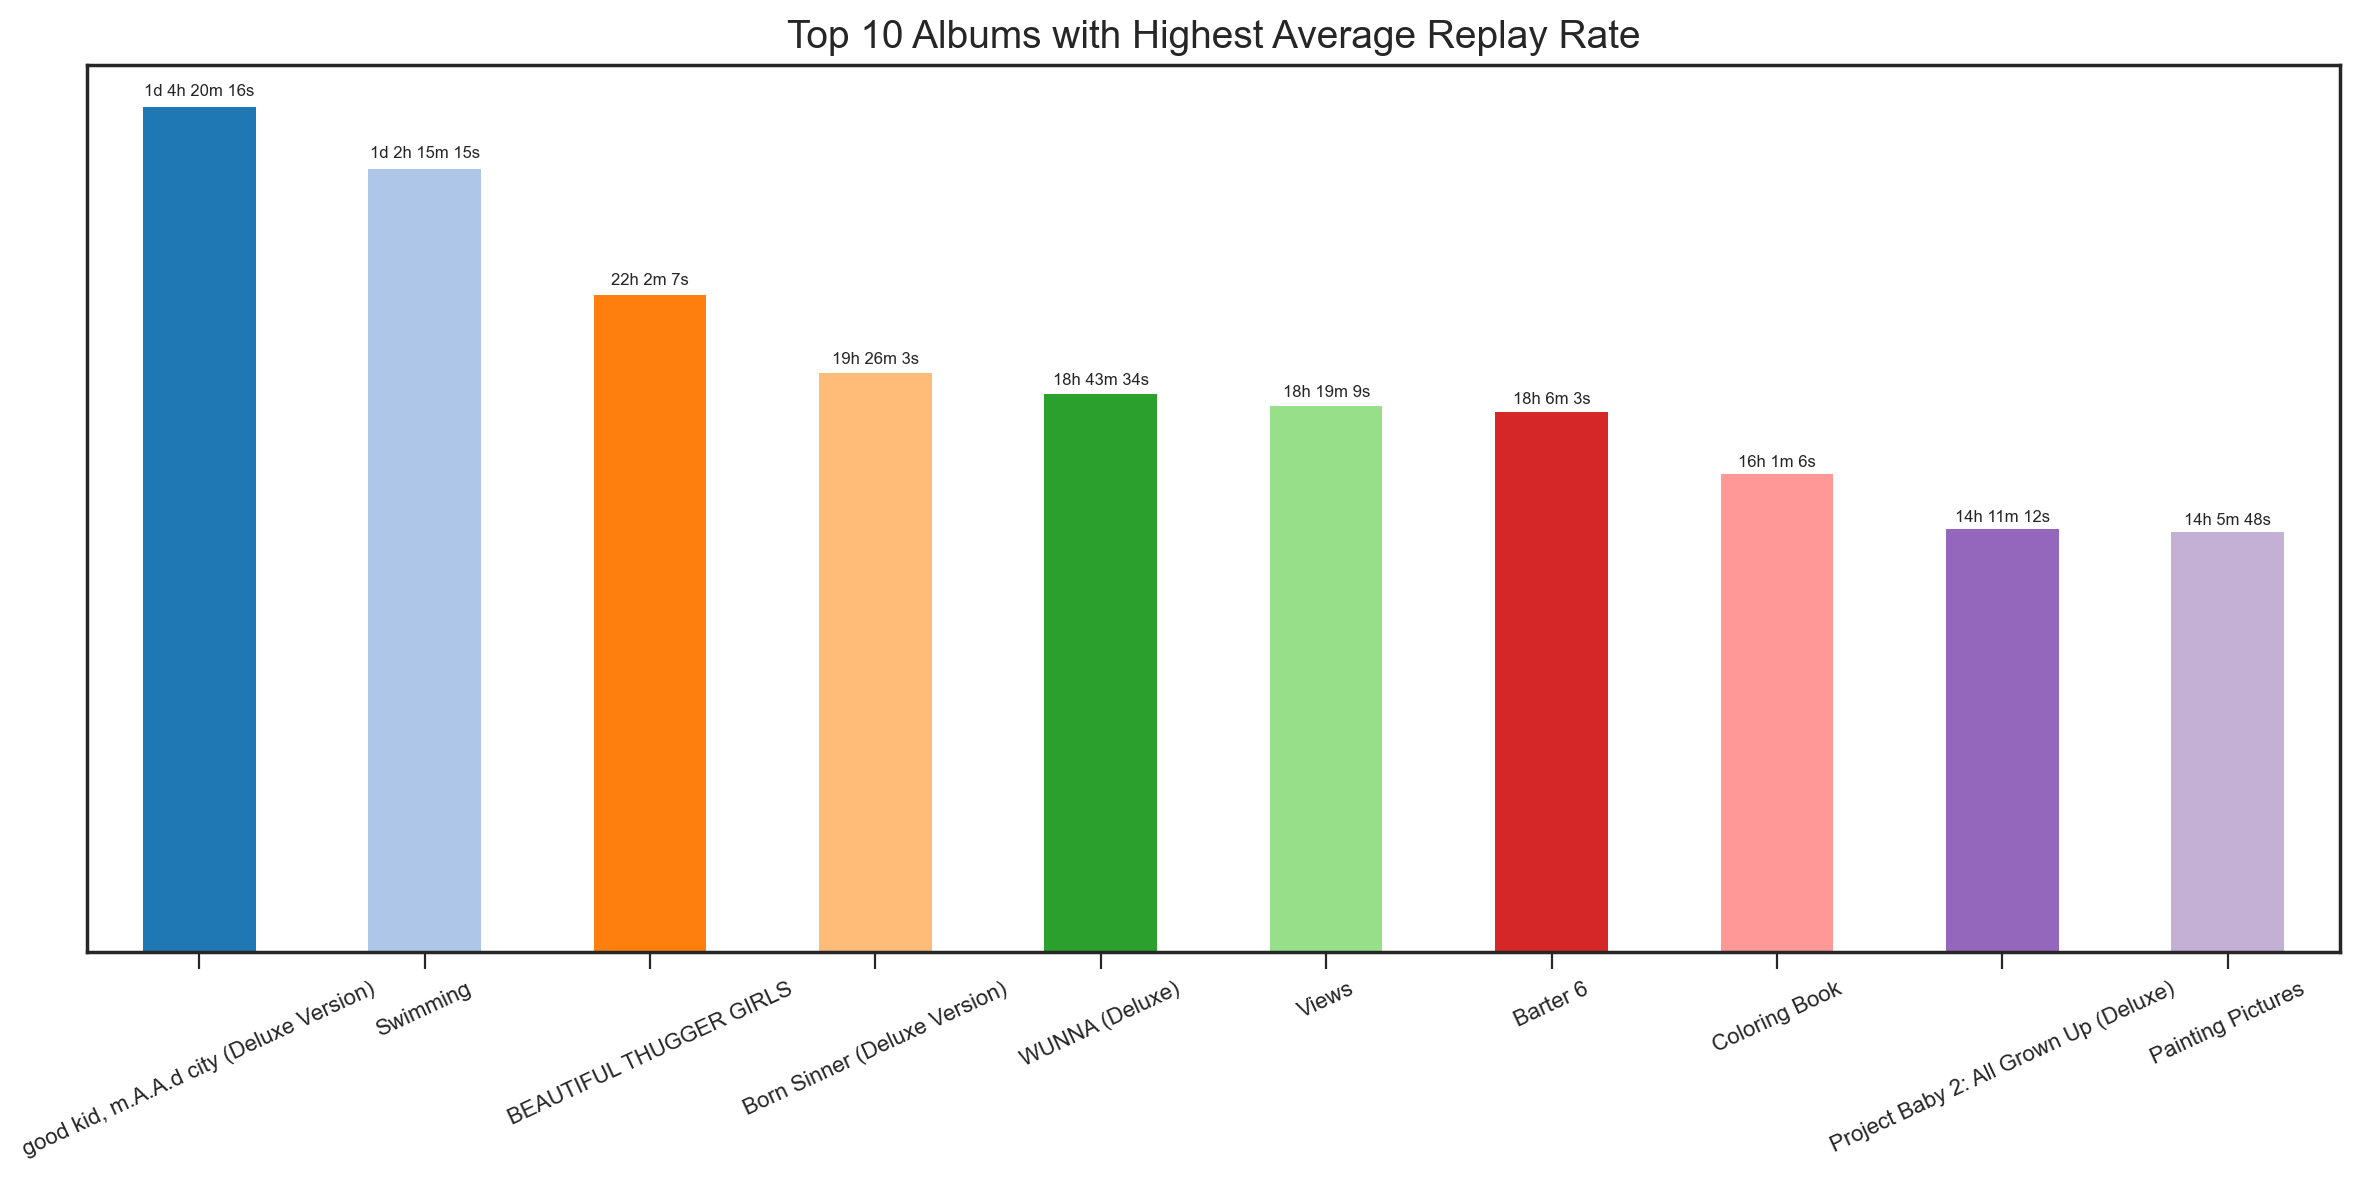

In [45]:
albums = song_df.groupby('Album')['Listening Time (ms)'].sum().sort_values(ascending=False)
albums = albums.head(10)

plt.figure(dpi=200, figsize=(12,6))
albums.plot(kind='bar', color=cm.tab20.colors)
for i, value in enumerate(albums):
    label = ms_to_hours(value)
    plt.text(i, value + value * 0.01, label, ha='center', va='bottom', fontsize=6)
plt.xlabel('')
plt.xticks(rotation=25, fontsize=8)
plt.yticks([])
plt.title('Top 10 Albums with Highest Average Replay Rate', fontsize=14)
plt.tight_layout()

# SONG STATS

### PLOT BOTTOM 10 SONGS BY SKIP RATE

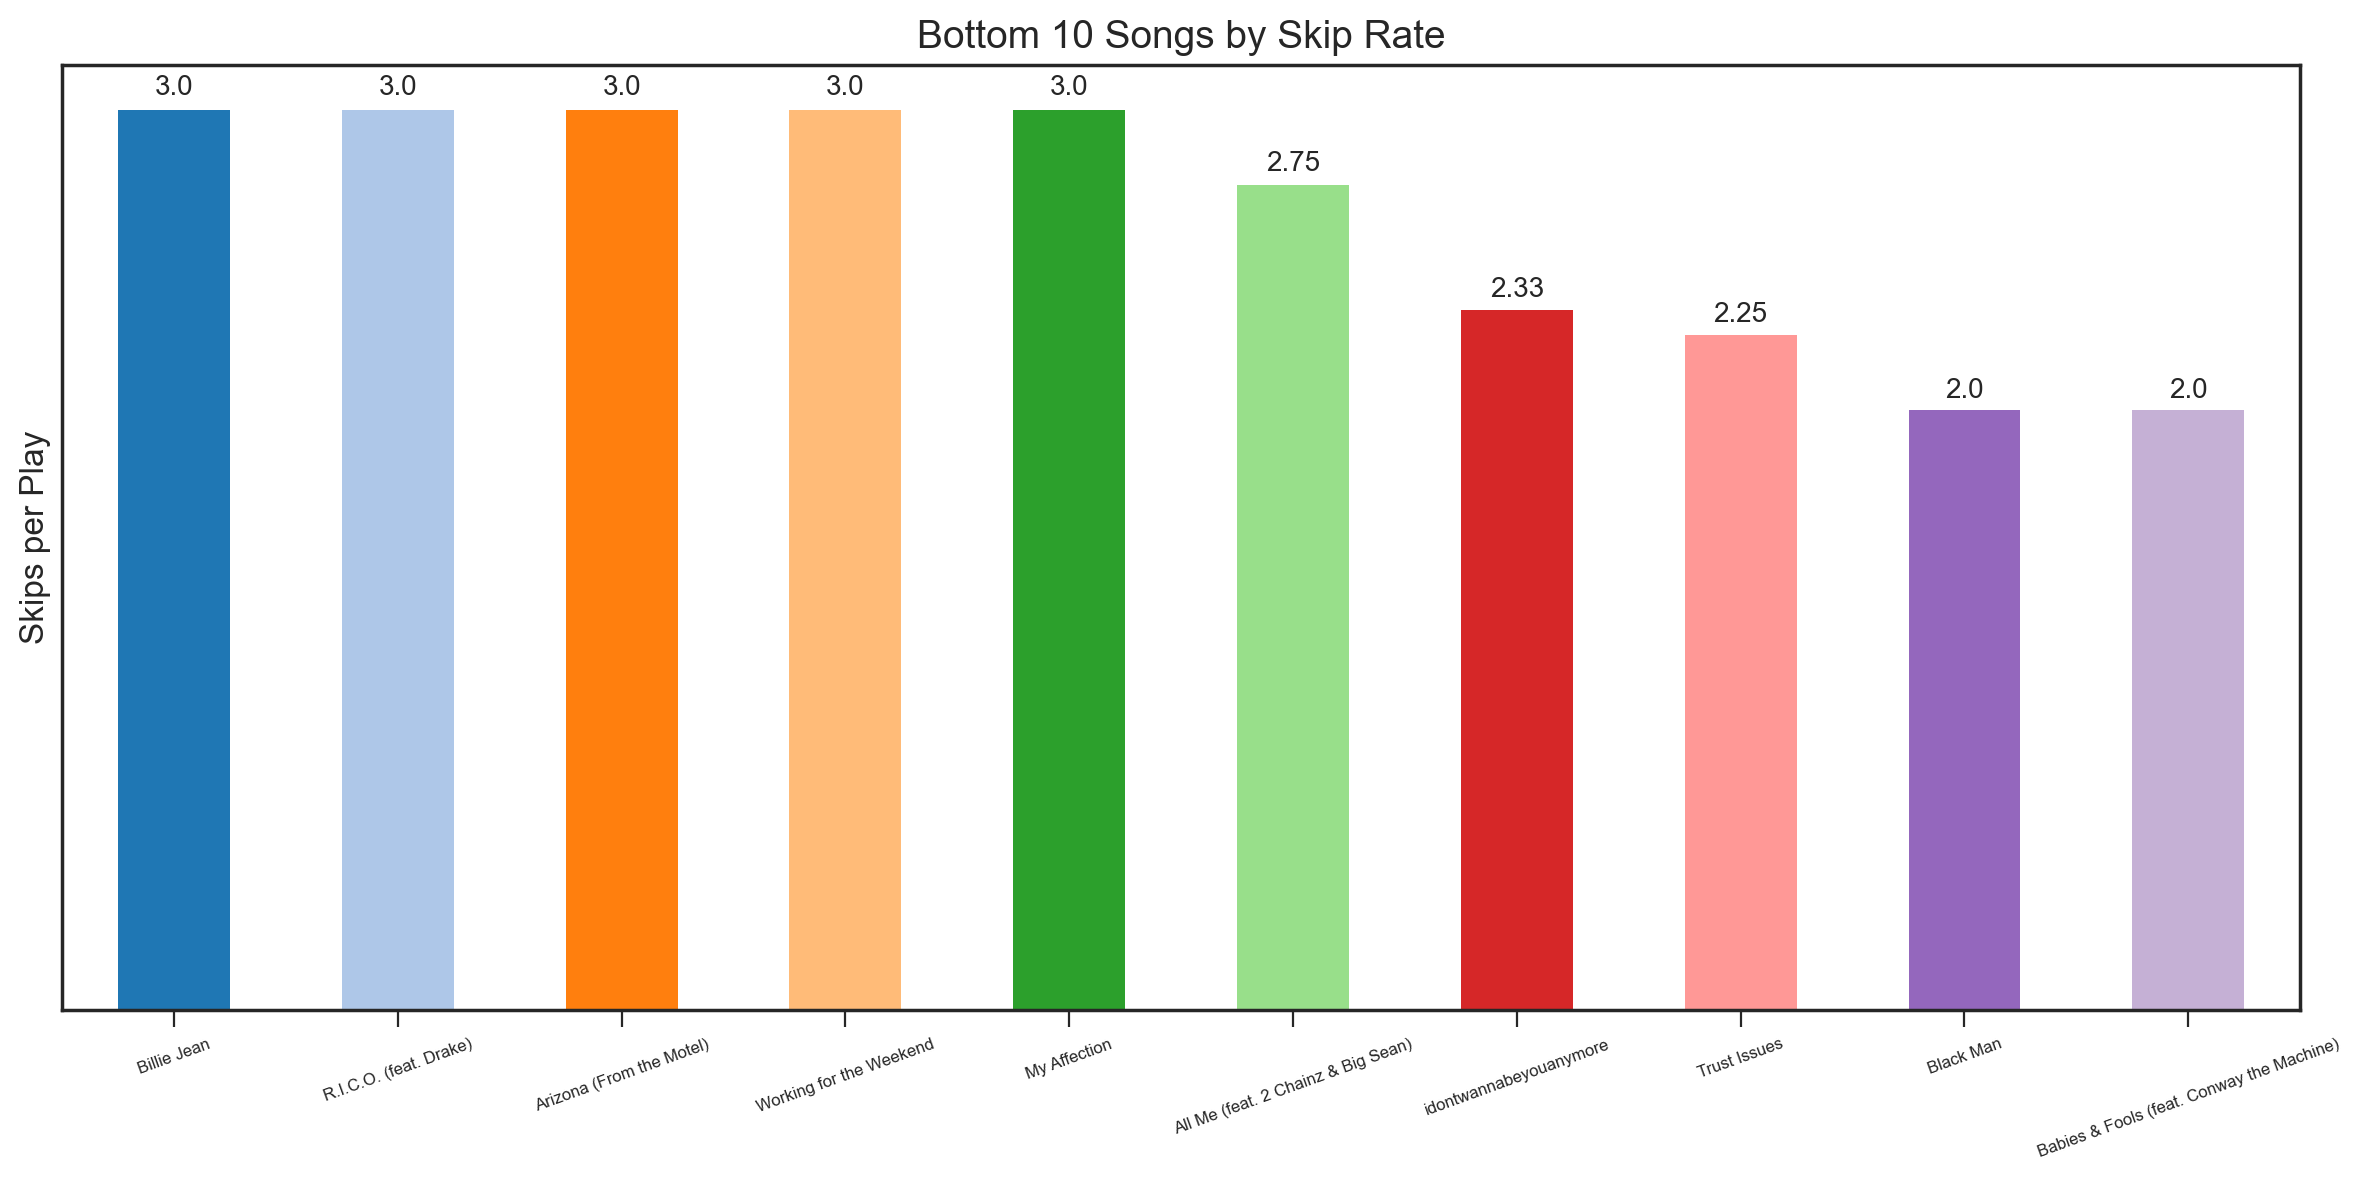

In [46]:
skips = song_df.groupby('Name')['Skip Count'].sum().astype(int).sort_values(ascending=False)
plays = song_df.groupby('Name')['Play Count'].sum().astype(int).sort_values(ascending=False)

skip_rate = (skips / plays).fillna(0).sort_values(ascending=False)
skip_rate = skip_rate[plays > 0]  # Filter out songs with zero plays
skip_rate_top = skip_rate.head(10)

plt.figure(dpi=200, figsize=(12,6))
skip_rate_top.plot(kind='bar', color=cm.tab20.colors)
for i, value in enumerate(skip_rate_top):
    label = str(np.round(value, 2))
    plt.text(i, value + value * 0.01, label, ha='center', va='bottom', fontsize=10)
plt.xlabel('', fontsize=12)
plt.ylabel('Skips per Play', fontsize=12)
plt.xticks(rotation=20, fontsize=6)
plt.yticks([])
plt.title('Bottom 10 Songs by Skip Rate', fontsize=14)
plt.tight_layout()


# LISTENING STATS

### PLOT LISTENING TIME BY DECADE

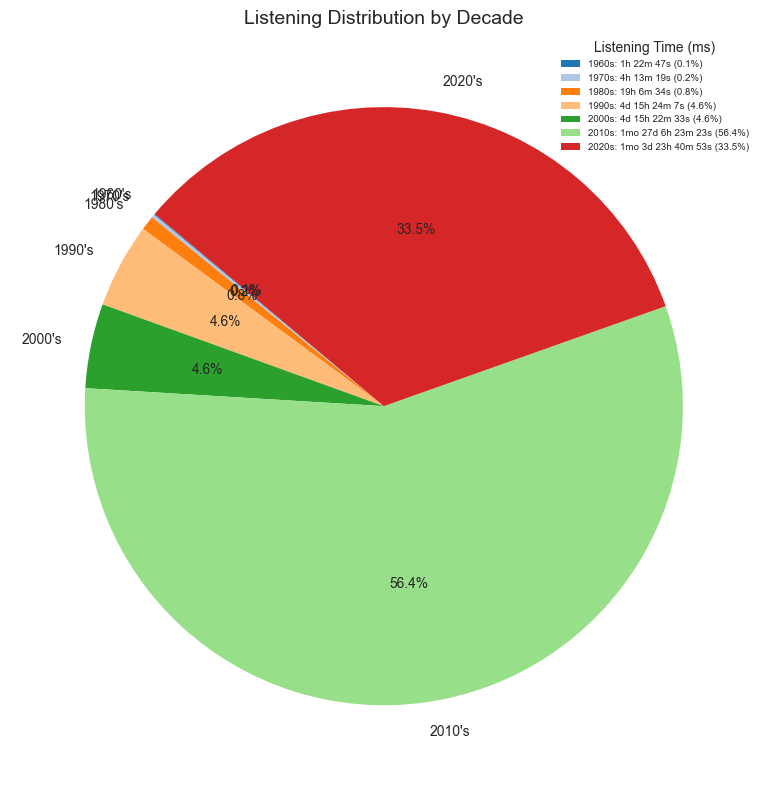

In [57]:
decade = song_df['Year'].apply(lambda x: (x // 10) * 10)
decade_lt = song_df['Listening Time (ms)'].groupby(decade).sum().sort_index()

labels_with_counts = [
    f"{int(decade)}s: {ms_to_hours(time)} ({time / decade_lt.sum():.1%})"
    for decade, time in decade_lt.items()
]
decade_lt.index = [f"{int(decade)}'s" for decade in decade_lt.index]  # Create decade labels with 's' (e.g., 1990s, 2000s)
decade_lt.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%', startangle=140, colors=cm.tab20.colors)
plt.title('Listening Distribution by Decade', fontsize=14)
plt.ylabel('')  # Hide the y-label for clarity
plt.legend(labels=labels_with_counts, title="Listening Time (ms)", fontsize=7)
plt.tight_layout()

### LISTENING ACTIVITY BY TIME AND WEEKDAY

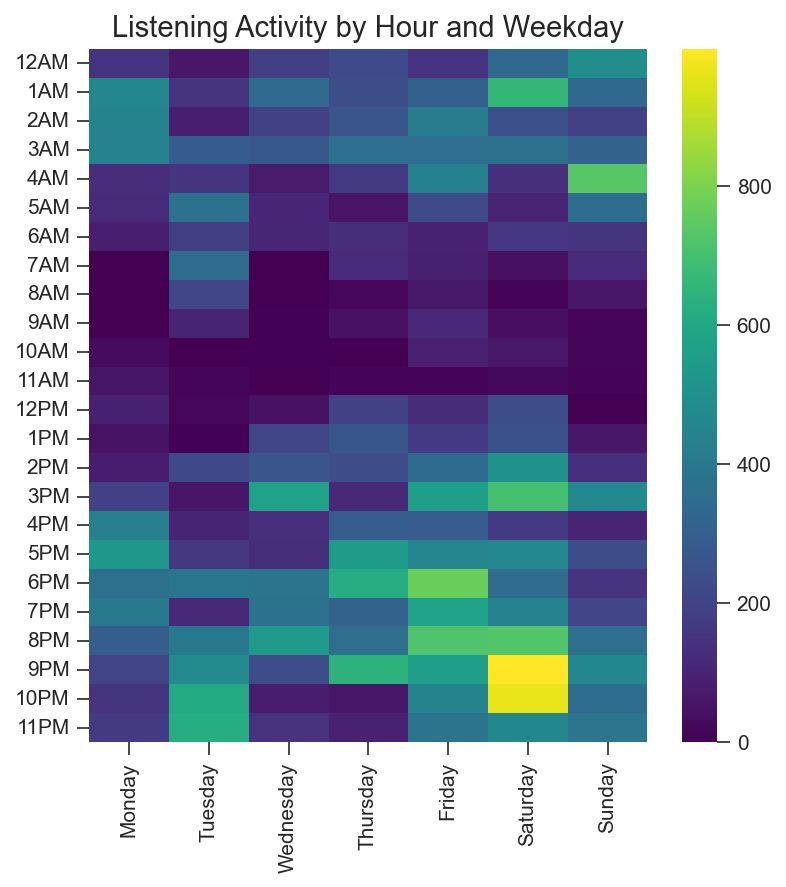

In [48]:
hour = song_df['Play Date'].dt.hour.fillna(0).astype(int)
song_df['Hour'] = hour.apply(lambda x: f"{(x % 12) or 12}{'AM' if x < 12 else 'PM'}")

song_df['Weekday'] = song_df['Play Date'].dt.day_name()

heatmap_data = song_df.pivot_table(
    index='Hour',
    columns='Weekday',
    values='Play Count',
    aggfunc='sum'
).fillna(0)

hour_order = [
'12AM','1AM','2AM','3AM','4AM','5AM','6AM','7AM','8AM','9AM','10AM','11AM',
'12PM','1PM','2PM','3PM','4PM','5PM','6PM','7PM','8PM','9PM','10PM','11PM'
]

heatmap_data = heatmap_data.reindex(hour_order)

weekday_order = [
'Monday',
'Tuesday',
'Wednesday',
'Thursday',
'Friday',
'Saturday',
'Sunday'
]

heatmap_data = heatmap_data[weekday_order]

plt.figure(figsize=(6, 6), dpi=150)
sns.heatmap(heatmap_data, cmap='viridis')

plt.title('Listening Activity by Hour and Weekday', fontsize=14)
plt.xlabel('')
plt.ylabel('')
plt.show()